In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cmocean as cm
import dask
import warnings
warnings.filterwarnings('ignore')

In [3]:
ds = xr.open_dataset("../data/oisst/NA_OISST_1995_2025.nc").sst.load()
clim = xr.open_dataset("../data/oisst/NA_OISST_1995_2025_clim.nc").sst.load()
per90 = xr.open_dataset("../data/oisst/NA_OISST_1995_2025_per90.nc").sst.load()

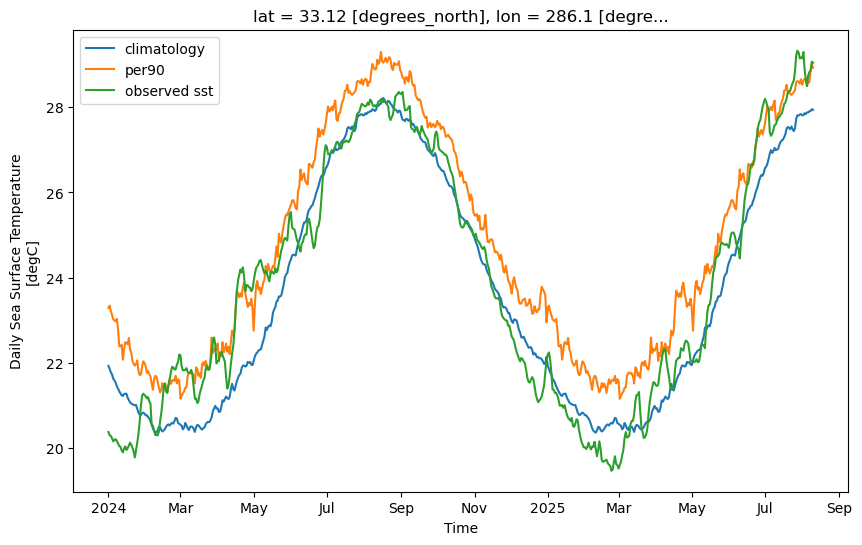

In [4]:
plt.figure(figsize=(10,6))
lat=33
lon=286
clim.sel(lat=lat, lon=lon, method='nearest').sel(time=slice("2024","2025")).plot(label='climatology')
per90.sel(lat=lat, lon=lon, method='nearest').sel(time=slice("2024","2025")).plot(label='per90')
ds.sel(lat=lat, lon=lon, method='nearest').sel(time=slice("2024","2025")).plot(label='observed sst')
plt.legend()
plt.show()

In [24]:
anom = (ds>per90).sel(lat=lat, lon=lon, method='nearest').sel(time=slice("2024","2024"))

In [25]:
anom

<xarray.DataArray 'sst' (time: 366)> Size: 366B
array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False, False,  True, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True,  True,  True,
       False, False, False, False,  True, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
...
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False])
Coordinates:
  * time     (time) datetime64[ns] 3kB 2024-01-01 2024-01-02 ... 2024-12-31
    lat      float32 4B 33.12
    lon      float32 4B 286.1

In [26]:
lat=33
lon=286
ds.sel(lat=lat, lon=lon, method='nearest').time.where(anom, drop=True)

<xarray.DataArray 'time' (time: 43)> Size: 344B
array(['2024-02-22T00:00:00.000000000', '2024-02-23T00:00:00.000000000',
       '2024-02-24T00:00:00.000000000', '2024-02-25T00:00:00.000000000',
       '2024-02-26T00:00:00.000000000', '2024-02-27T00:00:00.000000000',
       '2024-02-28T00:00:00.000000000', '2024-02-29T00:00:00.000000000',
       '2024-03-01T00:00:00.000000000', '2024-03-02T00:00:00.000000000',
       '2024-03-03T00:00:00.000000000', '2024-03-04T00:00:00.000000000',
       '2024-03-05T00:00:00.000000000', '2024-03-06T00:00:00.000000000',
       '2024-03-07T00:00:00.000000000', '2024-03-10T00:00:00.000000000',
       '2024-03-28T00:00:00.000000000', '2024-03-29T00:00:00.000000000',
       '2024-03-30T00:00:00.000000000', '2024-04-04T00:00:00.000000000',
       '2024-04-18T00:00:00.000000000', '2024-04-19T00:00:00.000000000',
       '2024-04-20T00:00:00.000000000', '2024-04-21T00:00:00.000000000',
       '2024-04-22T00:00:00.000000000', '2024-04-23T00:00:00.000000000',
       '2024-04-24T00:00:00.000000000', '2024-04-25T00:00:00.000000000',
       '2024-04-26T00:00:00.000000000', '2024-04-27T00:00:00.000000000',
       '2024-04-28T00:00:00.000000000', '2024-04-29T00:00:00.000000000',
       '2024-04-30T00:00:00.000000000', '2024-05-01T00:00:00.000000000',
       '2024-05-02T00:00:00.000000000', '2024-05-03T00:00:00.000000000',
       '2024-05-04T00:00:00.000000000', '2024-05-05T00:00:00.000000000',
       '2024-05-06T00:00:00.000000000', '2024-05-07T00:00:00.000000000',
       '2024-05-08T00:00:00.000000000', '2024-05-09T00:00:00.000000000',
       '2024-05-10T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 344B 2024-02-22 2024-02-23 ... 2024-05-10
    lat      float32 4B 33.12
    lon      float32 4B 286.1
Attributes:
    long_name:     Time
    delta_t:       0000-00-01 00:00:00
    avg_period:    0000-00-01 00:00:00
    axis:          T
    actual_range:  [71222. 71586.]

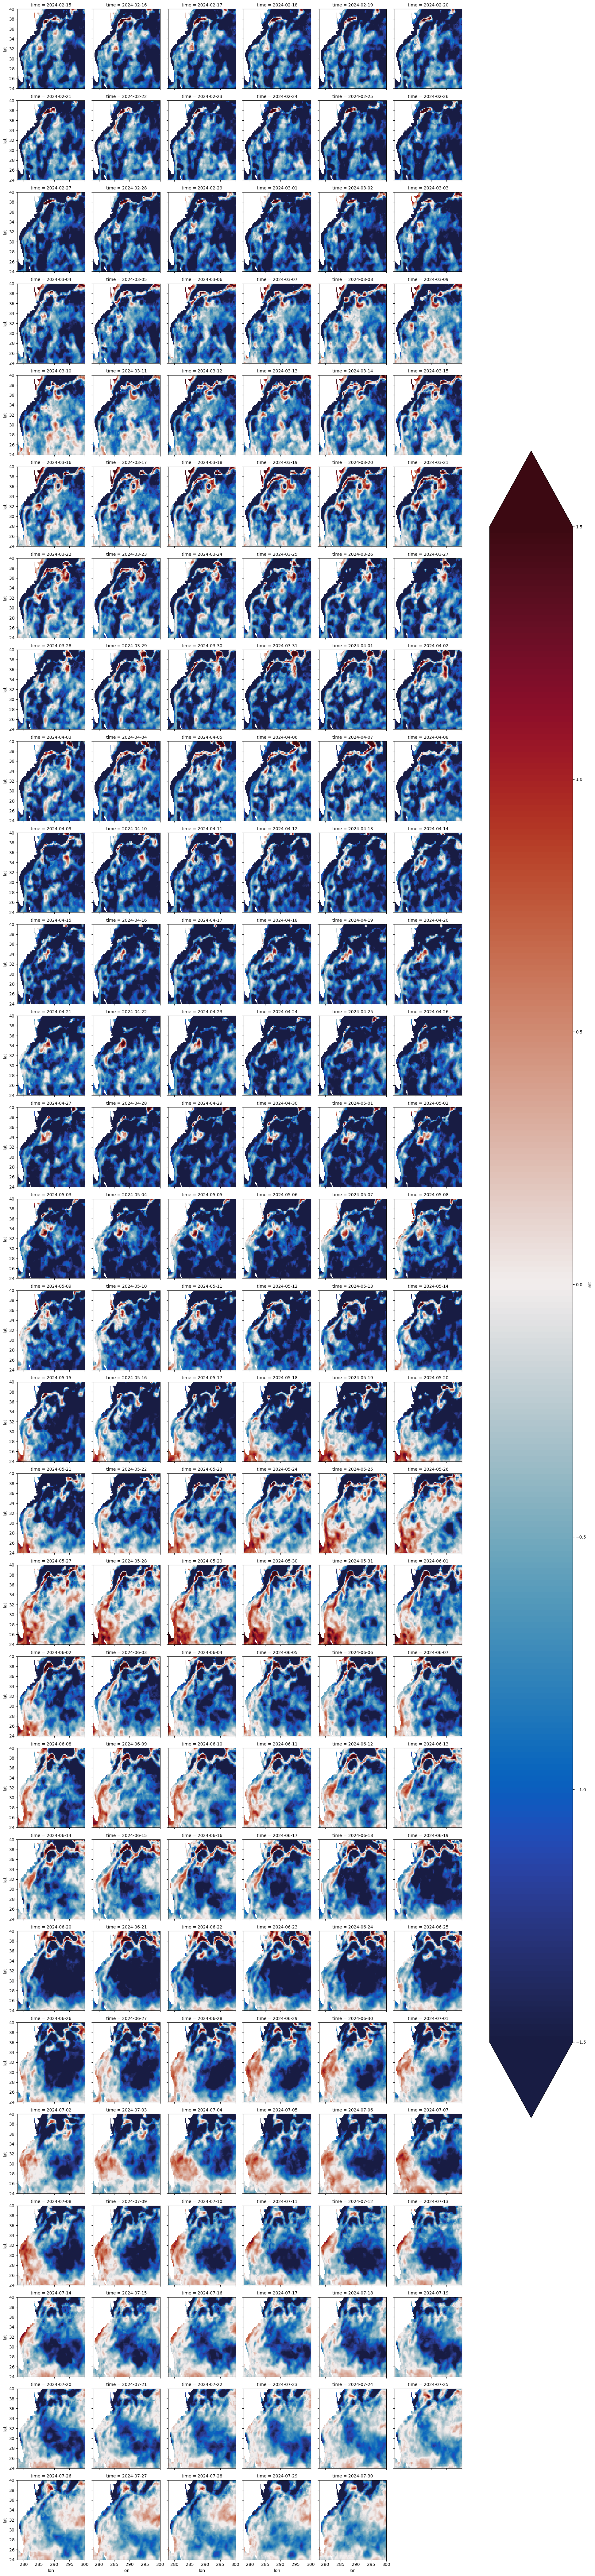

In [18]:
# (ds-per90).sel(lon=slice(278,300),lat=slice(24,40)).sel(time=slice("2025-05-25","2025-08-30")).plot(col="time", col_wrap=6,vmin=-1.5,vmax=1.5,cmap=cm.cm.balance)
(ds-per90).sel(lon=slice(278,300),lat=slice(24,40)).sel(time=slice("2024-02-15","2024-07-30")).plot(col="time", col_wrap=6,vmin=-1.5,vmax=1.5,cmap=cm.cm.balance)

# (ds > per90).sel(lon=slice(278,300),lat=slice(25,40)).sel(time=slice("2024-08-01","2024-08-15")).plot(col="time")
# plt.plot(286, 33, 'ro', markersize=10, markeredgecolor='r', 
#          markeredgewidth=2)

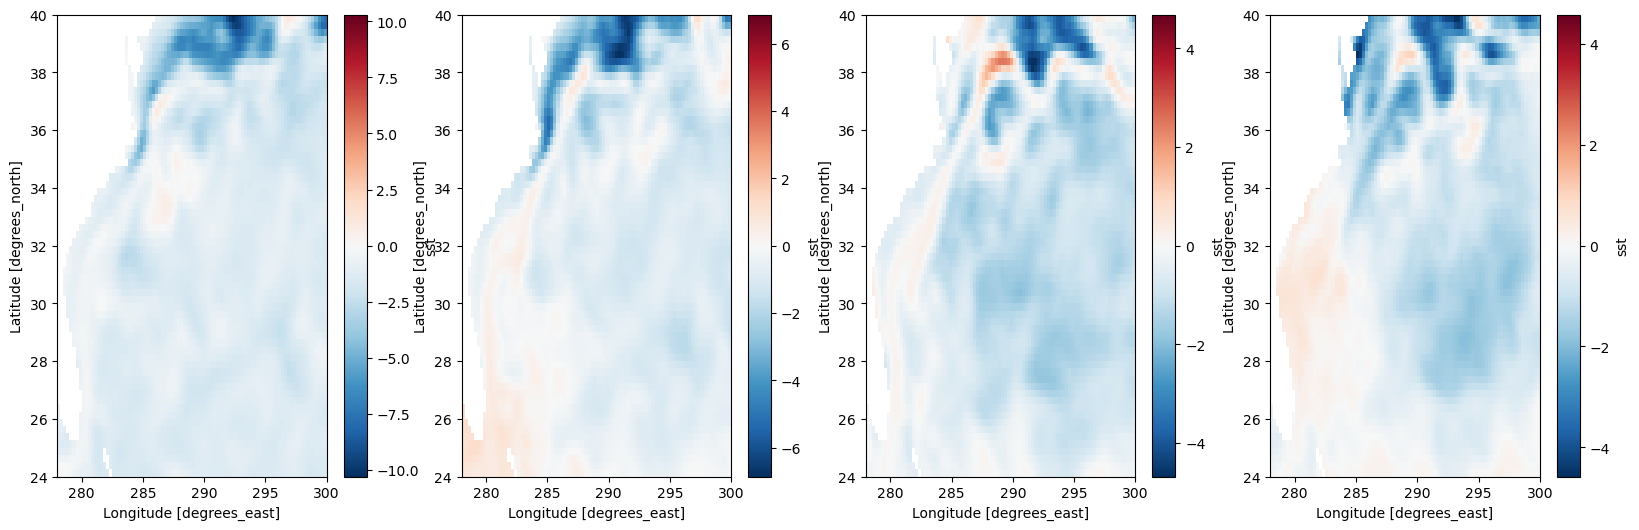

In [19]:
plt.figure(figsize=(20,6))
plt.subplot(1,4,1)
(ds-per90).sel(lon=slice(278,300),lat=slice(24,40)).sel(time=slice("2024-04-27","2024-05-14")).mean("time").plot()
plt.subplot(1,4,2)
(ds-per90).sel(lon=slice(278,300),lat=slice(24,40)).sel(time=slice("2024-05-15","2024-06-04")).mean("time").plot()
plt.subplot(1,4,3)
(ds-per90).sel(lon=slice(278,300),lat=slice(24,40)).sel(time=slice("2024-06-05","2024-06-25")).mean("time").plot()
plt.subplot(1,4,4)
(ds-per90).sel(lon=slice(278,300),lat=slice(24,40)).sel(time=slice("2024-06-26","2024-07-07")).mean("time").plot()

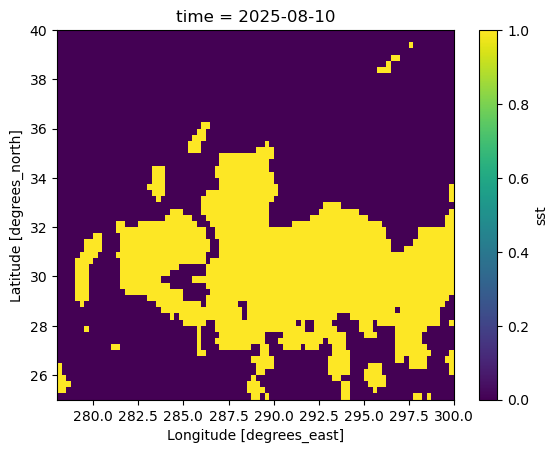

In [17]:
(ds > per90).sel(lon=slice(278,300),lat=slice(25,40)).isel(time=-1).plot()